## 1. Install and import libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [3]:
DATA_PATH = "/content/drive/MyDrive/web-page-phishing.csv"

# Set manually if the notebook selects the wrong target column.
# Common target names: Result, class, status, label, target, phishing"
TARGET_COLUMN = None

TEST_SIZE = 0.20
RANDOM_STATE = 42

## 3. Load the dataset

In [11]:
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
print(df.describe())
print("First five rows:")
display(df.head())

Dataset shape: (100077, 20)
          url_length         n_dots       n_hypens    n_underline  \
count  100077.000000  100077.000000  100077.000000  100077.000000   
mean       39.177683       2.224397       0.405188       0.137724   
std        47.971847       1.255046       1.285465       0.723995   
min         4.000000       1.000000       0.000000       0.000000   
25%        18.000000       2.000000       0.000000       0.000000   
50%        24.000000       2.000000       0.000000       0.000000   
75%        44.000000       2.000000       0.000000       0.000000   
max      4165.000000      24.000000      43.000000      21.000000   

             n_slash  n_questionmark        n_equal           n_at  \
count  100077.000000   100077.000000  100077.000000  100077.000000   
mean        1.135386        0.024391       0.215834       0.022143   
std         1.828526        0.167789       0.959802       0.268393   
min         0.000000        0.000000       0.000000       0.000000   


,url_length,n_dots,n_hypens,n_underline,n_slash,n_questionmark,n_equal,n_at,n_and,n_exclamation,n_space,n_tilde,n_comma,n_plus,n_asterisk,n_hastag,n_dollar,n_percent,n_redirection,phishing
0,37,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,77,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1
2,126,4,1,2,0,1,3,0,2,0,0,0,0,0,0,0,0,0,1,1
3,18,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,55,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


## 4. Dataset inspection

In [12]:
print("Columns:")
print(df.columns.tolist())

print("Dataset info:")
df.info()

print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Columns:
['url_length', 'n_dots', 'n_hypens', 'n_underline', 'n_slash', 'n_questionmark', 'n_equal', 'n_at', 'n_and', 'n_exclamation', 'n_space', 'n_tilde', 'n_comma', 'n_plus', 'n_asterisk', 'n_hastag', 'n_dollar', 'n_percent', 'n_redirection', 'phishing']
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100077 entries, 0 to 100076
Data columns (total 20 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   url_length      100077 non-null  int64
 1   n_dots          100077 non-null  int64
 2   n_hypens        100077 non-null  int64
 3   n_underline     100077 non-null  int64
 4   n_slash         100077 non-null  int64
 5   n_questionmark  100077 non-null  int64
 6   n_equal         100077 non-null  int64
 7   n_at            100077 non-null  int64
 8   n_and           100077 non-null  int64
 9   n_exclamation   100077 non-null  int64
 10  n_space         100077 non-null  int64
 11  n_tilde         100077 non-null  int64
 

,0
url_length,0
n_dots,0
n_hypens,0
n_underline,0
n_slash,0
n_questionmark,0
n_equal,0
n_at,0
n_and,0
n_exclamation,0


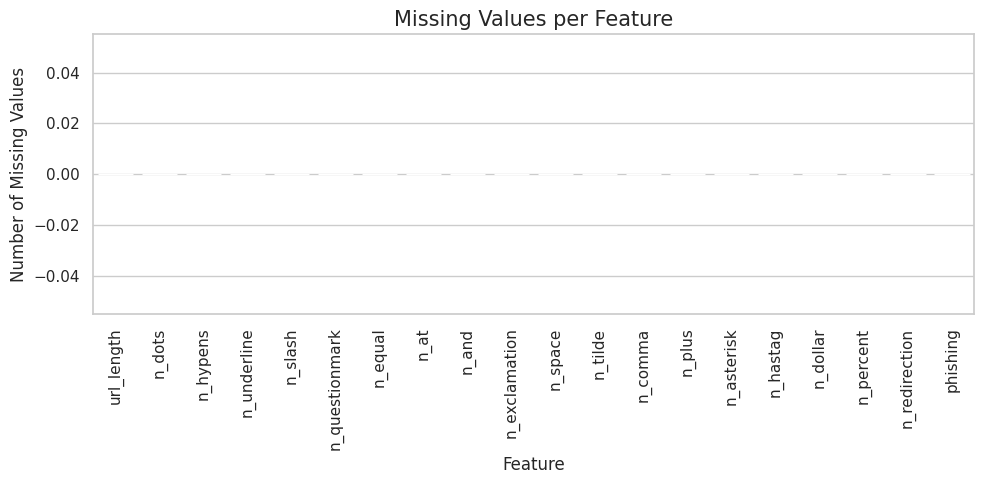

In [15]:
missing_values = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=90)
plt.title("Missing Values per Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.tight_layout()
plt.show()

## 5. Detect target column

In [8]:
def detect_target_column(dataframe):
    common_targets = [
        "Result", "result",
        "class", "Class",
        "status", "Status",
        "label", "Label",
        "target", "Target",
        "phishing", "Phishing",
        "type", "Type"
    ]

    for col in common_targets:
        if col in dataframe.columns:
            return col

    return dataframe.columns[-1]

if TARGET_COLUMN is None:
    TARGET_COLUMN = detect_target_column(df)

print("Selected target column:", TARGET_COLUMN)
print("Target values before encoding:")
print(df[TARGET_COLUMN].value_counts(dropna=False))

Selected target column: phishing
Target values before encoding:
phishing
0    63715
1    36362
Name: count, dtype: int64


In [13]:
data_quality = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().sum().values / len(df)) * 100,
    "Unique Values": df.nunique().values
})

display(data_quality)

,Column,Data Type,Missing Values,Missing %,Unique Values
0,url_length,int64,0,0.0,490
1,n_dots,int64,0,0.0,23
2,n_hypens,int64,0,0.0,33
3,n_underline,int64,0,0.0,22
4,n_slash,int64,0,0.0,25
5,n_questionmark,int64,0,0.0,6
6,n_equal,int64,0,0.0,22
7,n_at,int64,0,0.0,15
8,n_and,int64,0,0.0,21
9,n_exclamation,int64,0,0.0,10


# **6.Duplicate analysis**

Rows before duplicate removal: 21891
Duplicate rows: 0
Duplicate percentage: 0.0 %


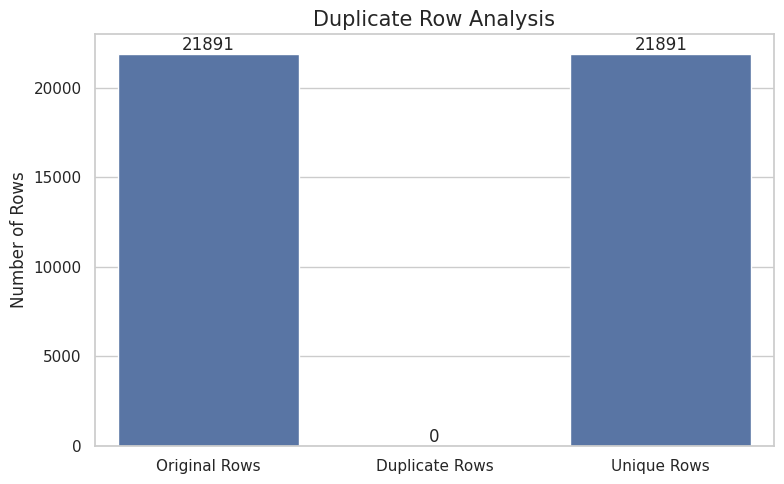

In [18]:
total_rows_before = df.shape[0]
duplicate_rows = df.duplicated().sum()

print("Rows before duplicate removal:", total_rows_before)
print("Duplicate rows:", duplicate_rows)
print("Duplicate percentage:", round((duplicate_rows / total_rows_before) * 100, 2), "%")

duplicate_summary = pd.DataFrame({
    "Category": ["Original Rows", "Duplicate Rows", "Unique Rows"],
    "Count": [
        total_rows_before,
        duplicate_rows,
        total_rows_before - duplicate_rows
    ]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=duplicate_summary, x="Category", y="Count")
plt.title("Duplicate Row Analysis")
plt.xlabel("")
plt.ylabel("Number of Rows")

for index, value in enumerate(duplicate_summary["Count"]):
    plt.text(index, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

# **7. Clean and prepare data**

In [19]:
df_clean = df.drop_duplicates().copy()

print("Rows before cleaning:", df.shape[0])
print("Rows after duplicate removal:", df_clean.shape[0])
print("Rows removed:", df.shape[0] - df_clean.shape[0])

# Fill missing values if any exist
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == "object":
            df_clean[col] = df_clean[col].fillna("missing")
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum().sum())

Rows before cleaning: 21891
Rows after duplicate removal: 21891
Rows removed: 0

Missing values after cleaning:
0


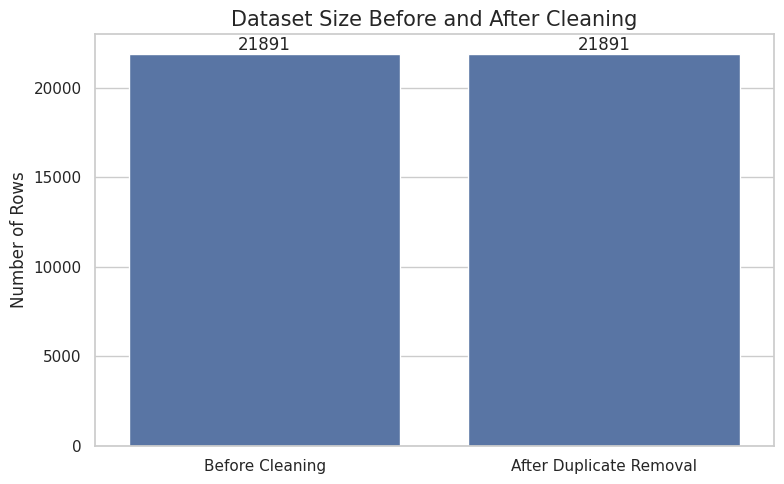

In [20]:
cleaning_comparison = pd.DataFrame({
    "Stage": ["Before Cleaning", "After Duplicate Removal"],
    "Rows": [df.shape[0], df_clean.shape[0]]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=cleaning_comparison, x="Stage", y="Rows")
plt.title("Dataset Size Before and After Cleaning")
plt.xlabel("")
plt.ylabel("Number of Rows")

for index, value in enumerate(cleaning_comparison["Rows"]):
    plt.text(index, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

# **8.Class balance plot**
Split into train and test first.
Balance only the training data.
Keep test data unchanged.

,Class,Count,Percentage
0,Legitimate,6019,27.495318
1,Phishing,15872,72.504682


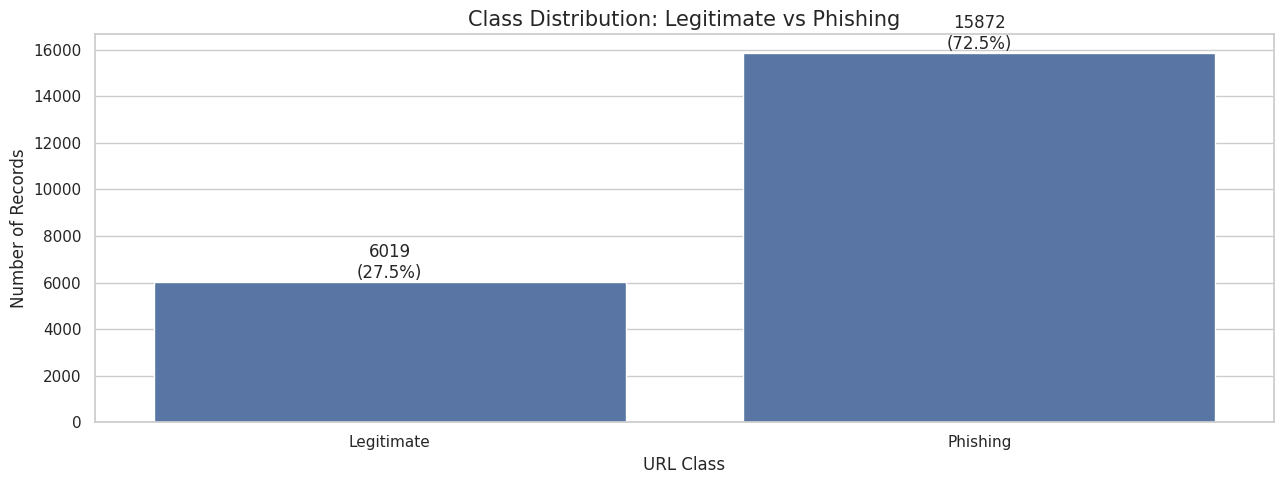

In [23]:
class_counts = df_clean[TARGET_COLUMN].value_counts().sort_index()

class_labels = {
    0: "Legitimate",
    1: "Phishing"
}

class_balance = pd.DataFrame({
    "Class": [class_labels[i] for i in class_counts.index],
    "Count": class_counts.values,
    "Percentage": (class_counts.values / class_counts.values.sum()) * 100
})

display(class_balance)

plt.figure(figsize=(13, 5))
sns.barplot(data=class_balance, x="Class", y="Count")
plt.title("Class Distribution: Legitimate vs Phishing")
plt.xlabel("URL Class")
plt.ylabel("Number of Records")

for index, row in class_balance.iterrows():
    plt.text(
        index,
        row["Count"],
        f'{row["Count"]}\n({row["Percentage"]:.1f}%)',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

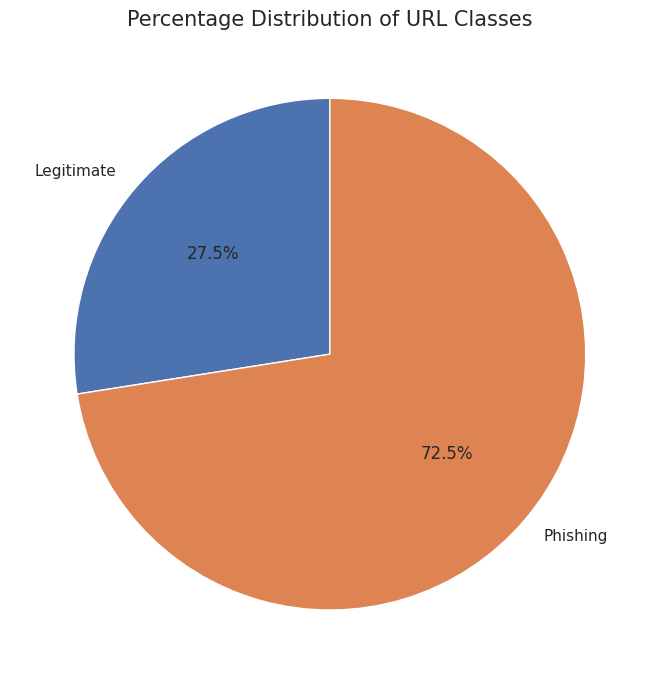

In [24]:
plt.figure(figsize=(7, 7))
plt.pie(
    class_balance["Count"],
    labels=class_balance["Class"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage Distribution of URL Classes")
plt.tight_layout()
plt.show()

# **Feature distribution overview**

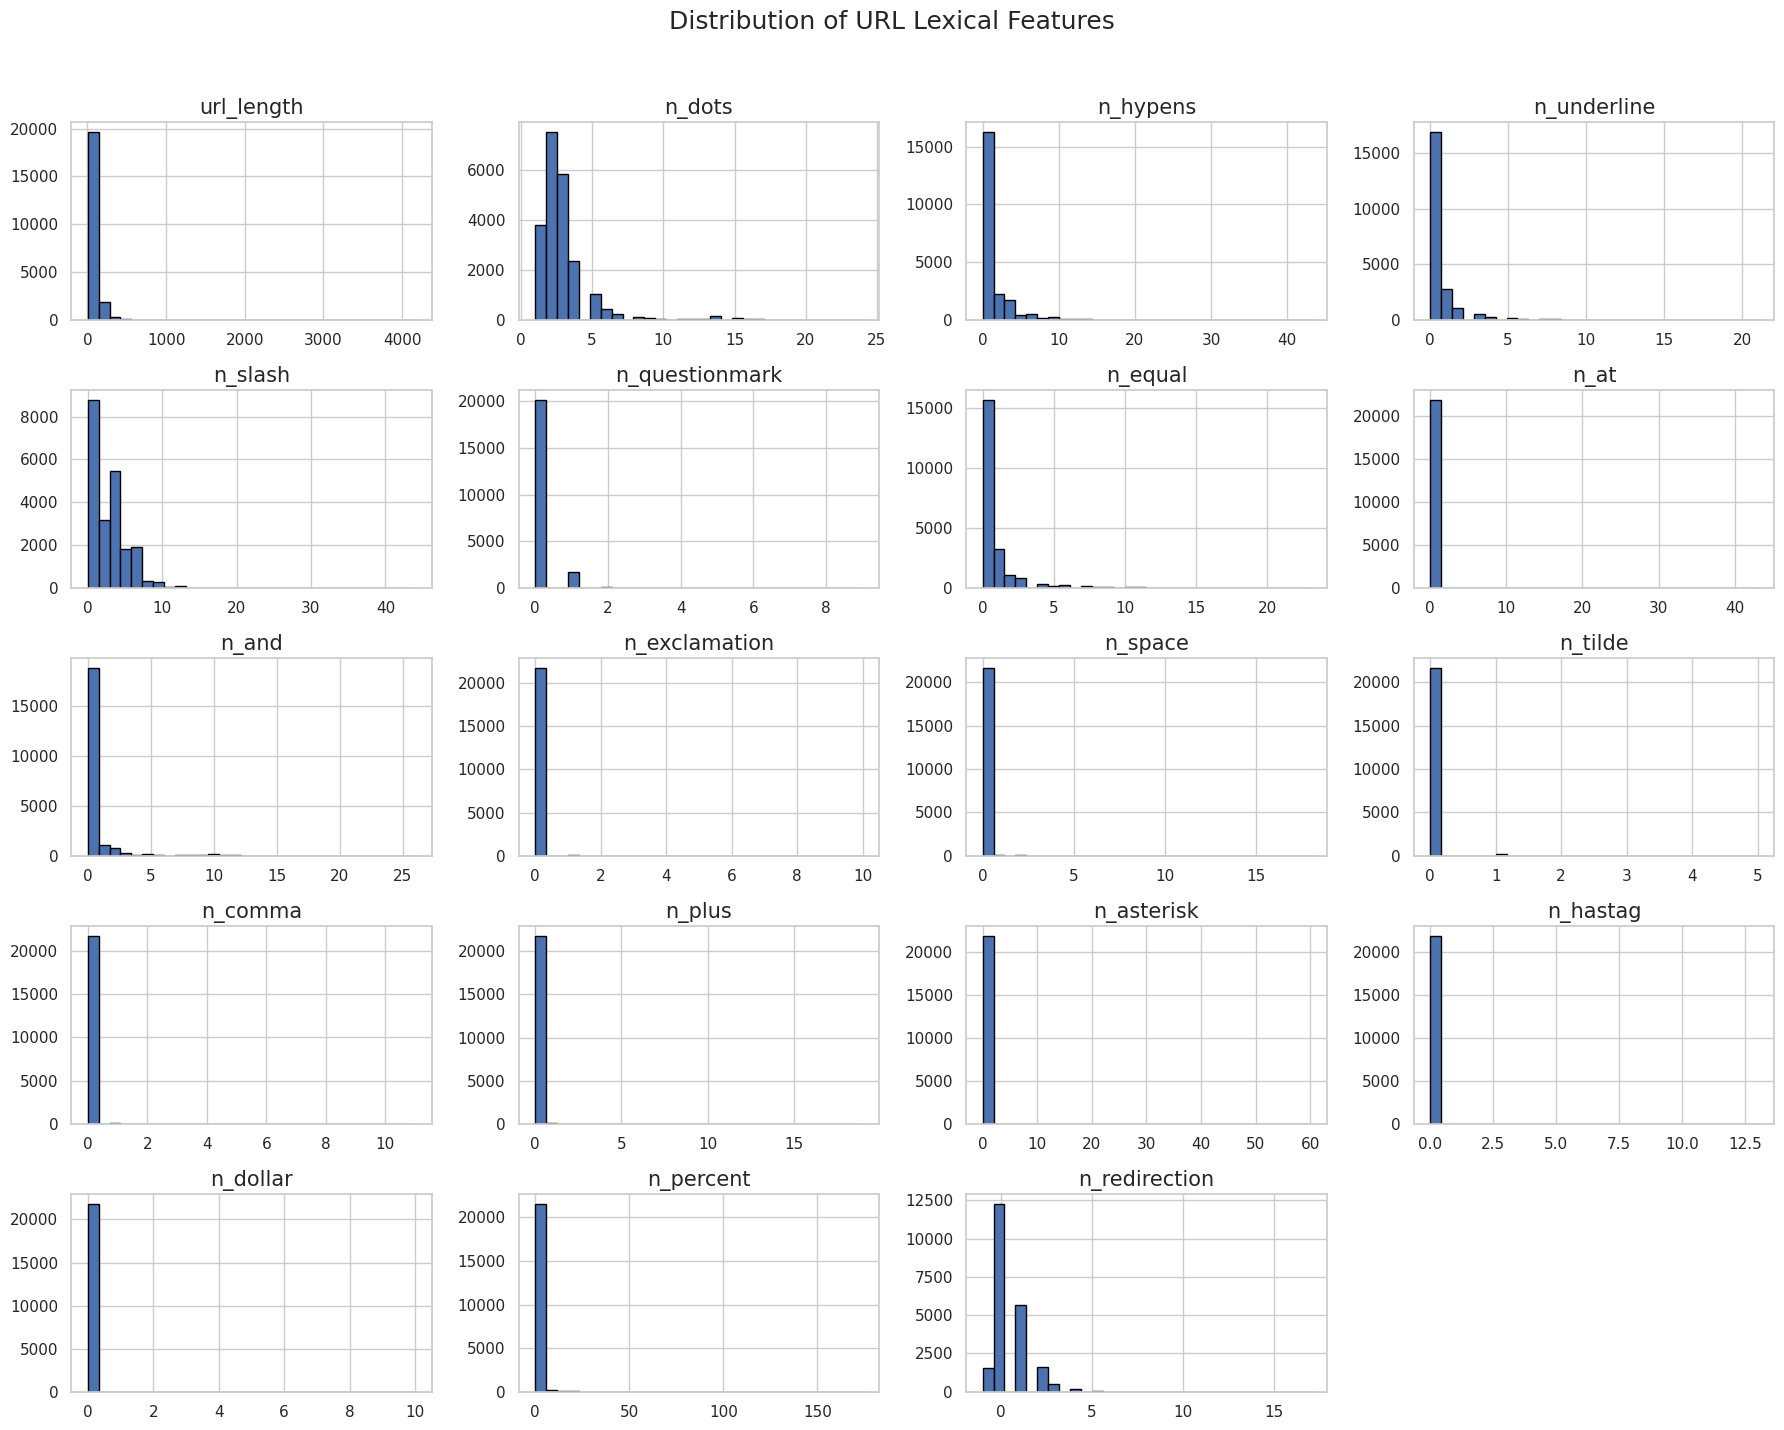

In [25]:
feature_cols = [col for col in df_clean.columns if col != TARGET_COLUMN]

df_clean[feature_cols].hist(
    bins=30,
    figsize=(18, 14),
    edgecolor="black"
)

plt.suptitle("Distribution of URL Lexical Features", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# **URL length comparison**

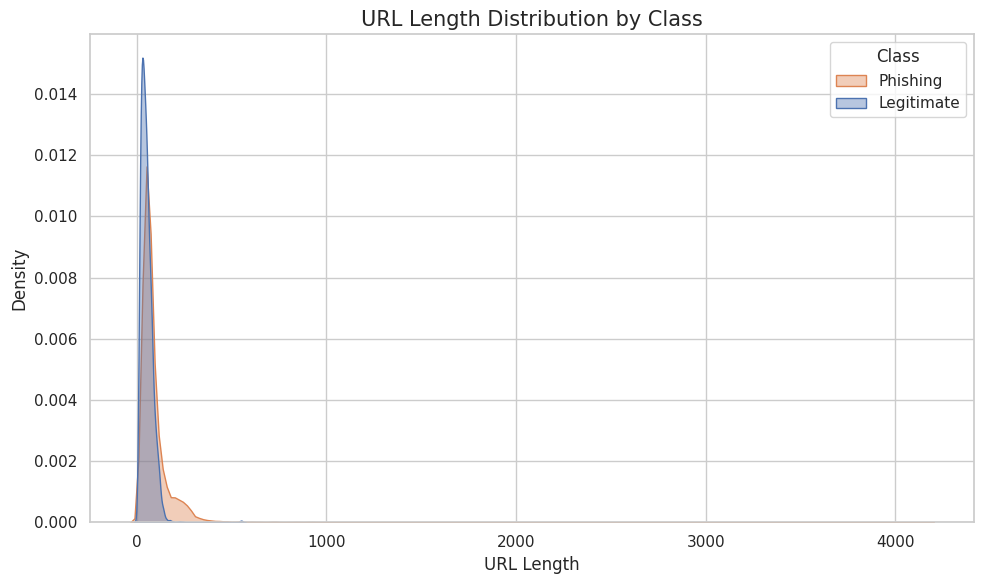

In [26]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=df_clean,
    x="url_length",
    hue=TARGET_COLUMN,
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("URL Length Distribution by Class")
plt.xlabel("URL Length")
plt.ylabel("Density")
plt.legend(title="Class", labels=["Phishing", "Legitimate"])
plt.tight_layout()
plt.show()

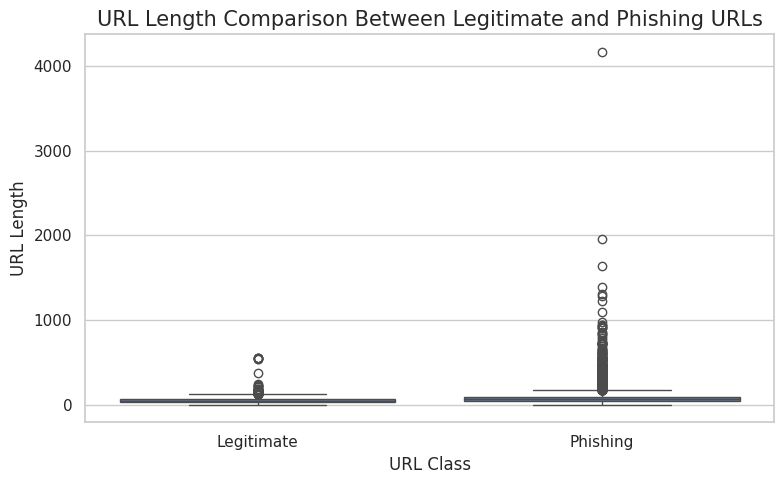

In [27]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x=TARGET_COLUMN,
    y="url_length"
)

plt.xticks([0, 1], ["Legitimate", "Phishing"])
plt.title("URL Length Comparison Between Legitimate and Phishing URLs")
plt.xlabel("URL Class")
plt.ylabel("URL Length")
plt.tight_layout()
plt.show()

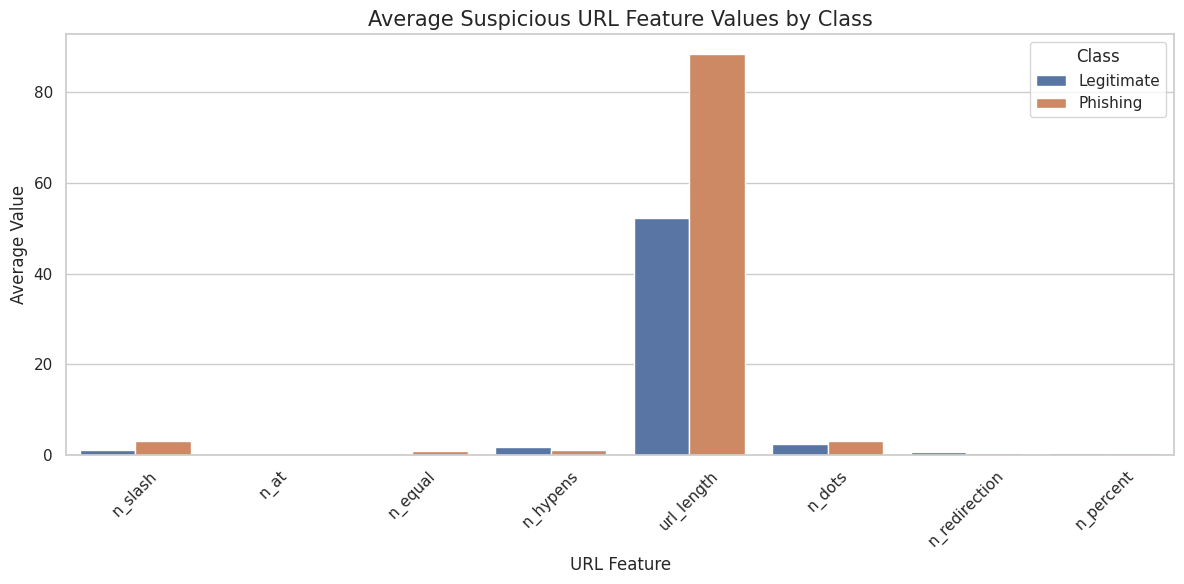

In [28]:
important_features = [
    "n_slash",
    "n_at",
    "n_equal",
    "n_hypens",
    "url_length",
    "n_dots",
    "n_redirection",
    "n_percent"
]

important_features = [col for col in important_features if col in df_clean.columns]

important_means = df_clean.groupby(TARGET_COLUMN)[important_features].mean().T
important_means.columns = ["Legitimate", "Phishing"]

important_means_plot = important_means.reset_index().rename(columns={"index": "Feature"})
important_means_plot = important_means_plot.melt(
    id_vars="Feature",
    value_vars=["Legitimate", "Phishing"],
    var_name="Class",
    value_name="Average Value"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=important_means_plot,
    x="Feature",
    y="Average Value",
    hue="Class"
)

plt.title("Average Suspicious URL Feature Values by Class")
plt.xlabel("URL Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,url_length_group,Count,Phishing_Rate
0,0-25,1969,42.813611
1,26-50,6210,64.428341
2,51-75,6291,75.679542
3,76-100,3159,76.828110
4,101-150,2252,82.682060
5,151-200,723,97.372061
6,200+,1287,98.989899


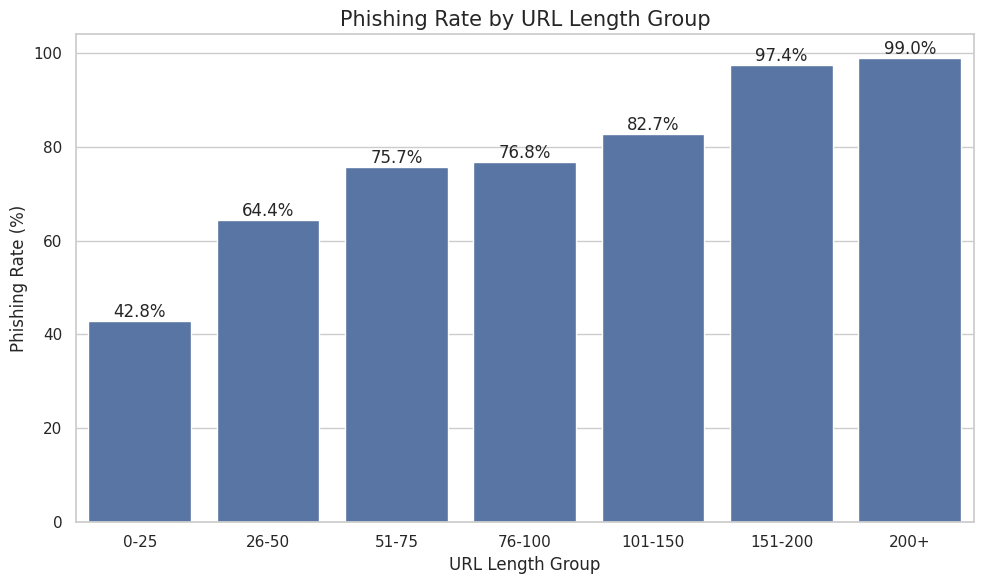

In [29]:
df_clean["url_length_group"] = pd.cut(
    df_clean["url_length"],
    bins=[0, 25, 50, 75, 100, 150, 200, np.inf],
    labels=["0-25", "26-50", "51-75", "76-100", "101-150", "151-200", "200+"]
)

url_length_group_analysis = df_clean.groupby("url_length_group")[TARGET_COLUMN].agg(
    Count="count",
    Phishing_Rate="mean"
).reset_index()

url_length_group_analysis["Phishing_Rate"] = url_length_group_analysis["Phishing_Rate"] * 100

display(url_length_group_analysis)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=url_length_group_analysis,
    x="url_length_group",
    y="Phishing_Rate"
)

plt.title("Phishing Rate by URL Length Group")
plt.xlabel("URL Length Group")
plt.ylabel("Phishing Rate (%)")

for index, row in url_length_group_analysis.iterrows():
    plt.text(
        index,
        row["Phishing_Rate"],
        f'{row["Phishing_Rate"]:.1f}%',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

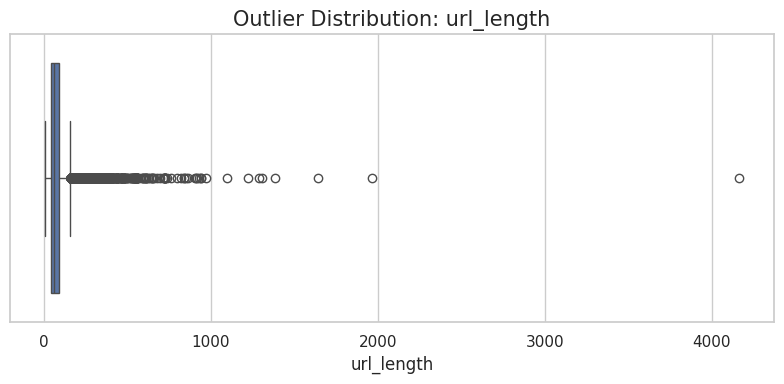

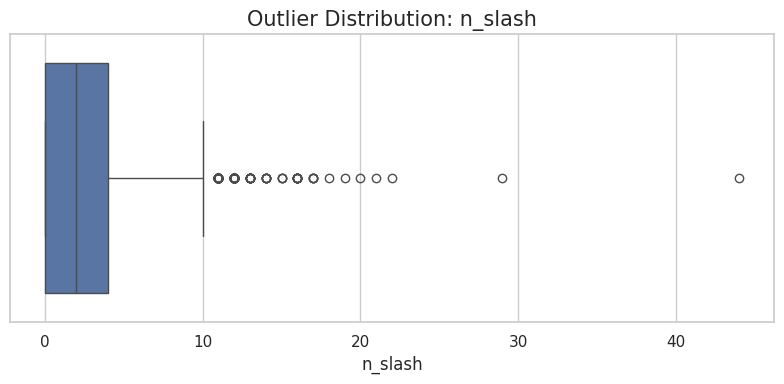

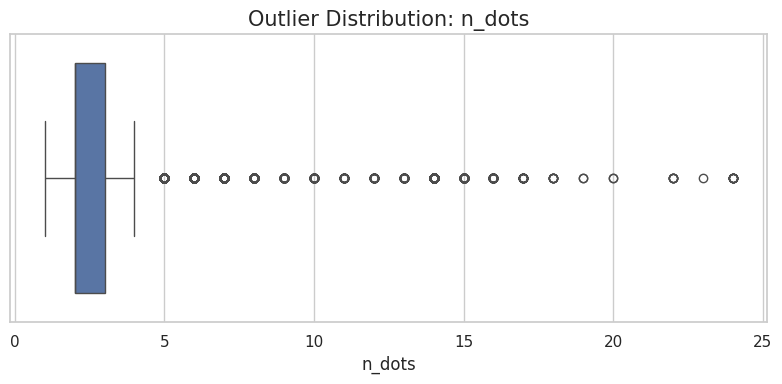

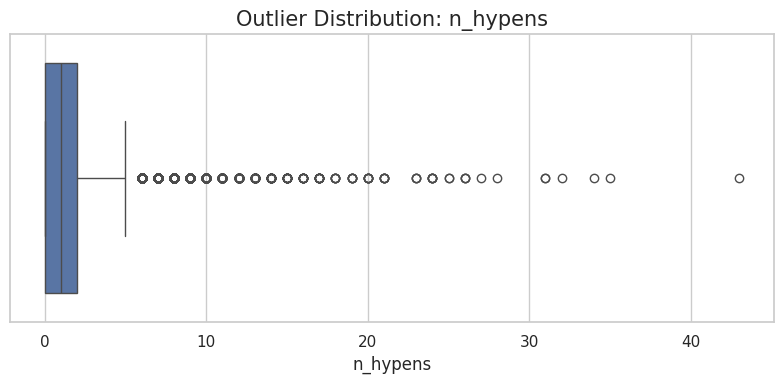

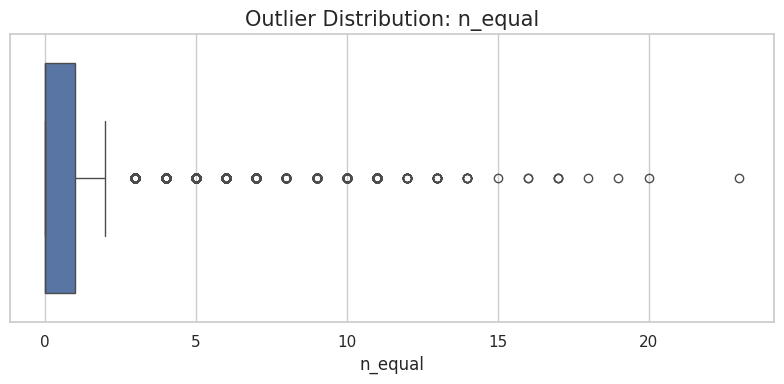

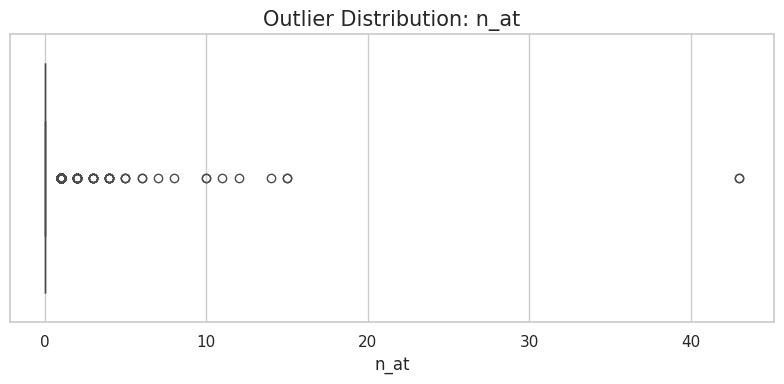

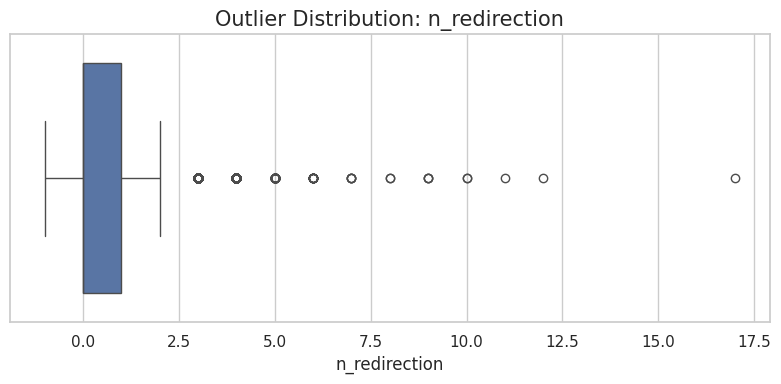

In [31]:
selected_features = [
    "url_length",
    "n_slash",
    "n_dots",
    "n_hypens",
    "n_equal",
    "n_at",
    "n_redirection"
]

selected_features = [col for col in selected_features if col in df_clean.columns]

for feature in selected_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df_clean, x=feature)
    plt.title(f"Outlier Distribution: {feature}")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

In [32]:
Q1 = df_clean["url_length"].quantile(0.25)
Q3 = df_clean["url_length"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

outliers = df_clean[df_clean["url_length"] > upper_bound]

print("Number of url_length outliers:", outliers.shape[0])
print("Outlier percentage:", round((outliers.shape[0] / df_clean.shape[0]) * 100, 2), "%")

print("\nClass distribution among URL length outliers:")
print(outliers["phishing"].value_counts())
print(outliers["phishing"].value_counts(normalize=True) * 100)

Q1: 41.0
Q3: 88.0
IQR: 47.0
Lower bound: -29.5
Upper bound: 158.5
Number of url_length outliers: 1858
Outlier percentage: 8.49 %

Class distribution among URL length outliers:
phishing
1    1832
0      26
Name: count, dtype: int64
phishing
1    98.600646
0     1.399354
Name: proportion, dtype: float64


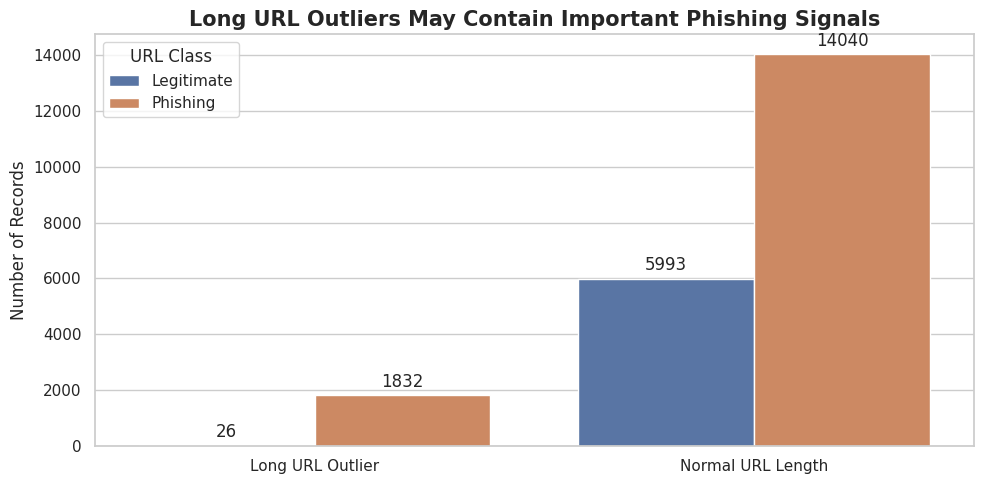

In [33]:
df_outlier_check = df_clean.copy()

df_outlier_check["URL Length Group"] = np.where(
    df_outlier_check["url_length"] > upper_bound,
    "Long URL Outlier",
    "Normal URL Length"
)

outlier_class = df_outlier_check.groupby(
    ["URL Length Group", "phishing"]
).size().reset_index(name="Count")

outlier_class["URL Class"] = outlier_class["phishing"].map({
    0: "Legitimate",
    1: "Phishing"
})

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=outlier_class,
    x="URL Length Group",
    y="Count",
    hue="URL Class"
)

plt.title("Long URL Outliers May Contain Important Phishing Signals", fontweight="bold")
plt.xlabel("")
plt.ylabel("Number of Records")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

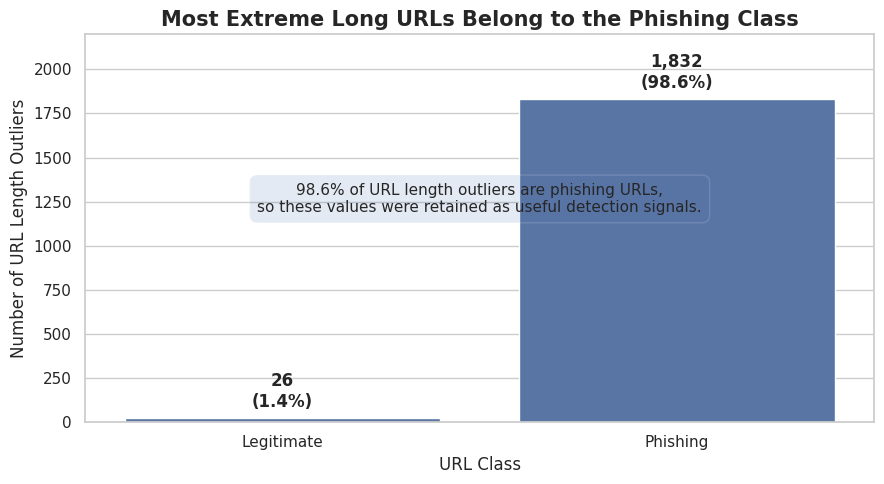

In [34]:
# Storytelling plot: URL length outliers are mostly phishing

outlier_summary = pd.DataFrame({
    "URL Class": ["Legitimate", "Phishing"],
    "Count": [26, 1832]
})

outlier_summary["Percentage"] = (
    outlier_summary["Count"] / outlier_summary["Count"].sum()
) * 100

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=outlier_summary,
    x="URL Class",
    y="Count"
)

plt.title(
    "Most Extreme Long URLs Belong to the Phishing Class",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("URL Class")
plt.ylabel("Number of URL Length Outliers")

for index, row in outlier_summary.iterrows():
    ax.text(
        index,
        row["Count"] + 40,
        f"{int(row['Count']):,}\n({row['Percentage']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.text(0.5,max(outlier_summary["Count"]) * 0.65,"98.6% of URL length outliers are phishing URLs,\nso these values were retained as useful detection signals.",ha="center",fontsize=11,bbox=dict(boxstyle="round,pad=0.5", alpha=0.15))

plt.ylim(0, max(outlier_summary["Count"]) * 1.2)
plt.tight_layout()
plt.show()